> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib networkx numpy pandas


In [ ]:
# 本案例需要数据文件；若已在 notebook 旁边则跳过下载
import os, urllib.parse, urllib.request
BASES = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/notebooks/zh/ATM_Cash_Management/',
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/zh/ATM_Cash_Management/',
]
FILES = [
    'atm_transactions.csv',
]
for f in FILES:
    if os.path.exists(f):
        continue
    os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
    for b in BASES:
        try:
            urllib.request.urlretrieve(b + urllib.parse.quote(f), f)
            break
        except Exception:
            continue
missing = [f for f in FILES if not os.path.exists(f)]
print(len(FILES) - len(missing), '/', len(FILES), 'data file(s) ready')
if missing:
    print('NOT FETCHED:', missing)

In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

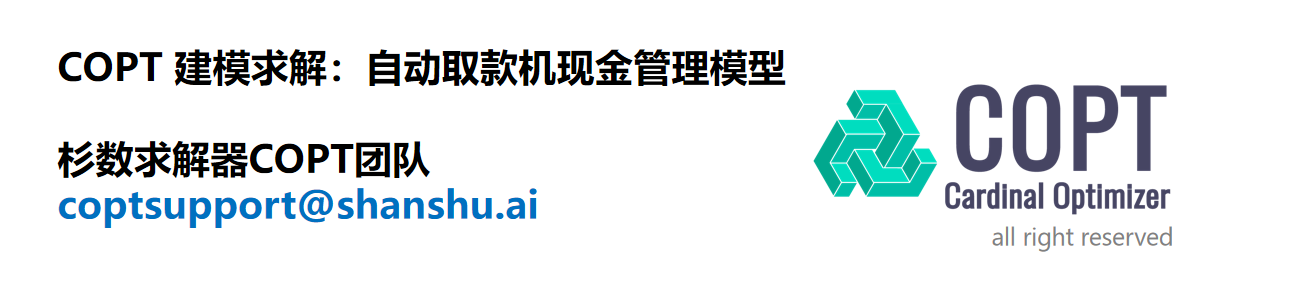

# 自动取款机现金管理模型代码实现

## 建模求解MIP问题步骤

在Python中调用COPT对MIP问题进行建模和求解的基本步骤如下：

1. 导入 `coptpy` 包

2. 添加/导入模型测试**数据**

3. 创建**求解环境**和求解**模型**

4. 构建模型，依次添加**模型三要素**
    - 添加**决策变量**：整数型（或0-1型）以及连续型
    - 设置**目标函数**
    - 添加**约束条件**


5. **求解**

6. 查看和分析求解**结果**

## 添加测试数据和参数

In [1]:
import numpy as np
import pandas as pd

**1. 设定ATM数量、运钞车数量、和考虑的周期**

In [3]:
# 涉及的的ATM数量
Natms = 10

# 涉及的的运钞车数量
Nvehicles = 8

# 涉及的的周期
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# 周期数量
Ndays = len(DAYS)

**2. 添加ATM取款需求和存款需求的原数据并提取示例数据，金额单位为（千元）**

In [5]:
# 输入原始数据
origin_df = pd.read_csv('atm_transactions.csv')
atm_transactions_df = origin_df.groupby(['atmid', 'day']).agg({'deposit': 'sum', 'withdraw': 'sum'}).reset_index()

# 提取示例数据
demo_atms = atm_transactions_df['atmid'].unique()[:Natms]
atm_transactions_demo_df = atm_transactions_df[atm_transactions_df['atmid'].isin(demo_atms)]

**3. 创建集合**

In [7]:
# ATM的ID集合
ATMIDS = atm_transactions_demo_df['atmid'].unique()
# ATMID对应的编号集合
ATMSET = set(range(Natms))
# ATM的数量参数
Natms = len(ATMIDS)

# 运钞车对应的编号集合
VEHICLESET = set(range(Nvehicles))

# 时间对应的编号集合
DAYSET = set(range(Ndays))

**4. 生成取款需求和存款需求相关的数据表**

In [9]:
# 每个ATM预期的现金存款金额
deposit_df = atm_transactions_demo_df.pivot(index='atmid', columns='day', values='deposit')   # 存款的数据
deposit_df = deposit_df[DAYS]

# 每个ATM在周期内预期的平均现金存款金额
mean_deposit_df = atm_transactions_demo_df.groupby('atmid')['deposit'].agg(['mean']).reset_index()  # 每个ATM的平均存款数据
mean_deposit_df = mean_deposit_df['mean'].apply(lambda x: (round(x, 0))).tolist()

# 每个ATM在周期内预期的现金存款金额的标准差
std_deposit_df = atm_transactions_demo_df.groupby('atmid')['deposit'].agg(['std']).reset_index()  # 每个ATM取款存款的标准差
std_deposit_df = std_deposit_df['std'].apply(lambda x: (round(x, 0))).tolist()

# 每个ATM预期的现金取款金额
withdraw_df = atm_transactions_demo_df.pivot(index='atmid', columns='day', values='withdraw')  # 取款的数据
withdraw_df = withdraw_df[DAYS]

# 每个ATM在周期内预期的平均现金取款金额
mean_withdraw_df = atm_transactions_demo_df.groupby('atmid')['withdraw'].agg(['mean']).reset_index()  # 每个ATM的平均取款数据
mean_withdraw_df = mean_withdraw_df['mean'].apply(lambda x: (round(x, 0))).tolist()

# 每个ATM在周期内预期的现金取款金额的标准差
std_withdraw_df = atm_transactions_demo_df.groupby('atmid')['withdraw'].agg(['std']).reset_index()  # 每个ATM取款数据的标准差
std_withdraw_df = std_withdraw_df['std'].apply(lambda x: (round(x, 0))).tolist()

**5. 随机生成城市范围内的ATM坐标，计算ATM之间的距离，距离单位为（千米）**

In [11]:
# 生成ATM位置
np.random.seed(42)
atm_locations = {atm: (np.random.uniform(0, 10), np.random.uniform(0, 10)) for atm in ATMIDS}

# 计算ATM之间的距离
atm_distance = {} 
for i in range(len(ATMIDS)):
    for j in range(i, len(ATMIDS)):
        if i != j:
            loc_i = atm_locations[ATMIDS[i]]
            loc_j = atm_locations[ATMIDS[j]]
            distance = np.sqrt((loc_i[0] - loc_j[0]) ** 2 + (loc_i[1] - loc_j[1]) ** 2)
            atm_distance[(i, j)] = distance
            atm_distance[(j, i)] = distance

**6. 输入自定义的模型参数**

In [13]:
# 每辆运钞车能承载的现金最大容量
Vehicle_Capacity = [30000 for _ in range(Nvehicles)] 

# 每辆运钞车每天可行驶的里程限制
Distance_Capacity = [60 for _ in range(Nvehicles)] 

# ATM内可存放的现金最大容量
Atm_Capacity = [100000 for _ in ATMSET]

# ATM机内起始的现金金额
Atm_Initial = [std_withdraw_df[i] for i in ATMSET]  

# 银行起始可用于ATM现金分配的现金金额
CASH_INITIAL = 4000000  

# 每单位闲置现金带来的利息成本
INTEREST_RATE = 0.012  

# 每辆运钞车每天的使用成本
VEHICLE_COST = 1  

# 安全库存量和取款需求的标准差的比例关系
STOCK_RATIO = 1 

## 创建求解环境和求解模型

这是在Python中调用COPT建模和求解前必备的步骤：

In [15]:
import coptpy as cp
from coptpy import COPT

# 创建求解环境
env = cp.Envr()

# 创建求解模型
model = env.createModel(name="cash_management")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## 添加模型三要素

### 添加决策变量

1. 添加类型为 ``vtype=COPT.BINARY`` 的0-1变量 ``dum_y``、 ``z``、 ``w``、 ``x`` ；
2. 添加类型为 ``vtype=COPT.CONTINUOUS`` 连续变量 ``remains`` 、 ``y_plus`` 、 ``y_minus``、 ``v``、 ``u``。

In [17]:
remains = {}  # 添加代表在第$t$天遗留在ATM i中的闲置现金金额的决策变量，上限为ATM i的现金最大容量
for i in ATMSET:
    for t in range(Ndays):
        remains[i, t] = model.addVar(ub=Atm_Capacity[i], vtype=COPT.CONTINUOUS, name=f"remains{i}_{t}")

y_plus = {}  # 添加代表在第$t$天通过车k补充ATM i的现金金额的决策变量，上限为车k的现金最大容量
y_minus = {}  # 添加代表在第$t$天通过车k回收ATM i的现金金额的决策变量，上限为车k的现金最大容量
dum_y = {}  # 添加用于使在第$t$天ATM i不会被同时补充现金和回收现金的决策变量
z = {}  # 添加代表在第$t$天是否通过车k补充或回收ATM i中的现金的决策变量
v = {}  # 添加用于子路线消除约束的辅助变量
for i in ATMSET:
    for k in range(Nvehicles):
        for t in range(Ndays):
            y_plus[i, k, t] = model.addVar(ub=Atm_Capacity[i], vtype=COPT.CONTINUOUS, name=f"y_plus{i}_{k}_{t}")
            y_minus[i, k, t] = model.addVar(ub=Atm_Capacity[i], vtype=COPT.CONTINUOUS, name=f"y_minus{i}_{k}_{t}")
            dum_y[i, k, t] = model.addVar(vtype=COPT.BINARY, name=f"dum_y{i}_{k}_{t}")
            z[i, k, t] = model.addVar(vtype=COPT.BINARY, name=f"z{i}_{k}_{t}")
            v[i, k, t] = model.addVar(ub=Natms, vtype=COPT.CONTINUOUS, name=f"v{i}_{k}_{t}")

w = {}  # 添加代表在第$t$天是否使用车k的决策变量
for k in range(Nvehicles):
    for t in range(Ndays):
        w[k, t] = model.addVar(vtype=COPT.BINARY, name=f"w{k}_{t}")

x = {}  # 添加代表在第$t$天车k是否在ATM i后行驶去ATM j的决策变量
for i in ATMSET:
    for j in ATMSET - {i}:
        for k in range(Nvehicles):
            for t in range(Ndays):
                x[i, j, k, t] = model.addVar(vtype=COPT.BINARY, name=f"x_{i}_{j}_{k}_{t}")

u = {}  # 添加用于车的容量限制约束的辅助变量，代表在第$t$天从ATM i到ATM j途中的车内的现金金额，上限为车的承载现金容量      
for i in ATMSET:
    for j in ATMSET - {i}:
        for t in range(Ndays):
            u[i, j, t] = model.addVar(ub=Vehicle_Capacity[0], vtype=COPT.CONTINUOUS, name=f"u_{i}_{j}_{t}")

### 设置目标函数

目标函数由两类成本：总闲置现金产生的利率收益成本和总现金补充成本（及车辆的使用成本），``sense`` 指定优化方向为``COPT.MINIMIZE`` 。

$$
\begin{aligned}
Minimize \quad& INTEREST\_RATE * \sum_{t \in DAYSET} (\sum_{i \in ATMSET} remains_{i,t}) \\&+{VEHICLE\_COST} * \sum_{t \in DAYSET} (\sum_{k \in VEHICLESET} w_{k,t})
\end{aligned}
$$

In [19]:
obj = (INTEREST_RATE * cp.quicksum(remains[i, t] for i in ATMSET for t in range(Ndays)) +
       VEHICLE_COST * cp.quicksum(w[k, t] for k in range(Nvehicles) for t in range(Ndays)))
model.setObjective(obj, COPT.MINIMIZE)

<font color=#0000FF>
<b>提示：推荐使用quicksum()</b>
</font>   

这里我们用到COPT中的辅助函数quicksum()实现加和运算。虽然和Python中的内置函数sum()实现的功能一致，但是使用quicksum()的性能更好，它对求和过程进行了优化，因此速度更快、占用内存空间更少，比调用sum()（或直接使用加号运算符）性能上会好很多，特别针对大规模问题建模时。


### 添加约束条件

**1. 添加现金分配类约束：**

$$
\begin{aligned}
&\forall i \in ATMSET \setminus{\{0\}} \quad \forall t \in DAYSET:\\
&\quad \quad remains_{i,t} = remains_{i,t-1} + {deposit\_df}_{i,t} - {withdraw\_df}_{i,t} &&&(1.1.)\\
&\quad \quad remains_{i,t} \ge {STOCK\_RATIO} * {std\_withdraw\_df}_i,&&&(1.2.)\\ 
&\quad \quad + \sum_{k \in VEHICLESET} \left( y\_plus_{i,k,t} - y\_minus_{i,k,t} \right), \\
&\quad \quad remains_{i,t-1}+\sum_{k \in VEHICLESET} y\_plus_{i,k,t} \leq {Atm\_Capacity}_{i}.&&&(1.3.)\\
\\
&\forall i \in ATMSET \setminus{\{0\}} \quad \forall k \in VEHICLESET \quad \forall t \in DAYSET:\\
&\quad \quad y\_plus_{i,k,t} - y\_minus_{i,k,t} \leq {Vehicle\_Capacity}_{k} * z_{i,k,t}, &&&(1.4.1.)\\
&\quad \quad y\_plus_{i,k,t} - y\_minus_{i,k,t} \ge z_{i,k,t}, &&&(1.4.2.)\\
&\quad \quad y\_plus_{i,k,t}  \le {Atm\_Capacity}_i * (1 - dum\_y_{i,k,t}),&&&(1.5.1.) \\
&\quad \quad y\_minus_{i,k,t}  \le {Atm\_Capacity}_i * dum\_y_{i,k,t}.&&&(1.5.2.)\\
\\
&\forall t \in DAYSET:\\
&\quad \quad\sum_{i \in ATMSET} \sum_{k \in VEHICLESET} y\_plus_{i,k,t} \leq {CASH\_INITIAL}\\
&\quad \quad +\sum_{i \in ATMSET} \sum_{k \in VEHICLESET}\sum_{h \in [0,1,...,t-1]}( y\_minus_{i,k,h} - y\_plus_{i,k,h}).&&&(1.6.)\\
\end{aligned}
$$

In [21]:
for i in ATMSET - {0}:
    for t in range(Ndays):
        model.addConstr(remains[i, t] >= STOCK_RATIO * std_withdraw_df[i], name=f"1.2.Constraint_{i}_{t}")
        if t != 0:
            model.addConstr(remains[i, t] == remains[i, t - 1] + deposit_df.iloc[i, t] - withdraw_df.iloc[i, t] + 
                            cp.quicksum(y_plus[i, k, t] - y_minus[i, k, t] for k in range(Nvehicles)), name=f"1.1.Constraint_{i}_{t}")
            model.addConstr(remains[i, t - 1] + cp.quicksum(y_plus[i, k, t] for k in range(Nvehicles))
                            <= Atm_Capacity[i], name=f"1.3.Constraint_{i}_{t}")
        else:
            model.addConstr(remains[i, 0] == Atm_Initial[i] + deposit_df.iloc[i, 0] - withdraw_df.iloc[i, 0] +
                            cp.quicksum(y_plus[i, k, 0] - y_minus[i, k, 0] for k in range(Nvehicles)),
                            name=f"1.2.Constraint_{i}_{0}")
            model.addConstr(Atm_Initial[i] + cp.quicksum(y_plus[i, k, 0] for k in range(Nvehicles)) <= Atm_Capacity[i],
                            name=f"1.3.Constraint_{i}_{0}")
        for k in range(Nvehicles):
            model.addConstr(y_plus[i, k, t] + y_minus[i, k, t] <= Vehicle_Capacity[k] * z[i, k, t],
                            name=f"1.4.1.Constraint_{i}_{k}_{t}")
            model.addConstr(y_plus[i, k, t] + y_minus[i, k, t] >= z[i, k, t], name=f"1.4.2.Constraint_{i}_{k}_{t}")
            model.addConstr(y_plus[i, k, t] <= Atm_Capacity[i] * (1 - dum_y[i, k, t]), name=f"1.5.1.Constraint_{i}_{k}_{t}")
            model.addConstr(y_minus[i, k, t] <= Atm_Capacity[i] * dum_y[i, k, t], name=f"1.5.2.Constraint_{i}_{k}_{t}")
            
for t in range(Ndays):
    if t != 0:
        model.addConstr(cp.quicksum(y_plus[i, k, t] for i in ATMSET - {0} for k in range(Nvehicles)) <=
                        CASH_INITIAL + cp.quicksum(y_minus[i, k, h] - y_plus[i, k, h]
                                                   for i in ATMSET - {0} for k in range(Nvehicles) for h in range(t - 1)),
                        name=f"1.6.Constraint_{t}")
    else:
        model.addConstr(cp.quicksum(y_plus[i, k, 0] for i in ATMSET - {0} for k in range(Nvehicles)) <= CASH_INITIAL,
                        name=f"1.6.Constraint_{0}")

**2. 添加路线规划类约束：**

$$
\begin{aligned}
&\forall t \in DAYSET:\\
&\quad \quad \sum_{j \in ATMSET\setminus\{0\}} x_{0,j,k,t} = w_{k,t},&&&(2.2.)\\
&\quad \quad \sum_{i,j \in ATMSET, i \neq j}( {atm\_distance}_{i,j}*x_{i,j,k,t}) \leq {Distance\_Capacity}_k.&&&(2.3.)\\
\\
&\forall i \in ATMSET \quad \forall k \in VEHICLESET \quad \forall t \in DAYSET:\\
&\quad \quad \sum_{j \in ATMSET-i}(x_{i,j,k,t}-x_{j,i,k,t}) = 0,&&&(2.4.)\\
&\quad \quad \sum_{j \in ATMSET-i}x_{j,i,k,t} = z_{i,k,t},&&&(2.5.)\\
&\quad \quad z_{i,k,t} \leq w_{k,t}.&&&(2.6.)\\
\\
&\forall i \in ATMSET\setminus\{0\} \quad \forall j \in ATMSET-\{0,i\} \\ & \forall k \in VEHICLESET \quad \forall t \in DAYSET:\\
&\quad \quad v_{j,k,t} \ge v_{i,k,t} +1-{Natms}*(1 - x_{i,j,k,t}).&&&(2.7.)\\
\\
&\forall i \in ATMSET-\setminus{\{0\}} \quad \forall t \in DAYSET:\\
&\quad \quad \sum_{k \in VEHICLESET} z_{i,k,t} \leq 1, &&&(2.1.)\\
&\quad \quad \sum_{j \in ATMSET-i}(u_{j,i,t}-u_{i,j,t}) = \sum_{k \in VEHICLESET}(y\_plus_{i,k,t}-y\_minus_{i,k,t}),&&&(2.8.1.)\\
&\quad \quad u_{i,j,t} \le {Vehicle\_Capacity}_{0} * \sum_{k \in VEHICLESET} x_{i,j,k,t}.&&&(2.8.2.)\\
\\
&\forall k \in range({Nvehicles}-1) \quad \forall t \in DAYSET:\\
&\quad \quad w_{k,t} \ge w_{k+1,t}.&&&(2.9.)\\
\end{aligned}
$$

In [23]:
for t in range(Ndays):
    for k in range(Nvehicles):
        model.addConstr(cp.quicksum(x[0, j, k, t] for j in ATMSET - {0}) == w[k, t], name=f"2.2.Constraint_{k}_{t}")
        model.addConstr(cp.quicksum(atm_distance[(i, j)] * x[i, j, k, t] for (i, j) in atm_distance.keys())
                        <= Distance_Capacity[k], name=f"2.3.Constraint_{k}_{t}")
        for i in ATMSET:
            model.addConstr(cp.quicksum(x[i, j, k, t] - x[j, i, k, t] for j in ATMSET - {i}) == 0, name=f"2.4.Constraint_{i}_{k}_{t}")
            if i != 0:
                model.addConstr(cp.quicksum(x[j, i, k, t] for j in ATMSET - {i}) == z[i, k, t], name=f"2.5.Constraint_{i}_{k}_{t}")
                model.addConstr(z[i, k, t] <= w[k, t], name=f"2.6.Constraint_{i}_{k}_{t}")
                for j in ATMSET - {0, i}:
                    model.addConstr(v[j, k, t] >= v[i, k, t] + 1 - Natms * (1 - x[i, j, k, t]), name=f"2.7.Constraint_{i}_{j}_{k}_{t}")

for i in ATMSET:
    for t in range(Ndays):
        if i != 0:
            model.addConstr(cp.quicksum(z[i, k, t] for k in range(Nvehicles)) <= 1, name=f"2.1.Constraint_{i}_{t}")
            model.addConstr(cp.quicksum(u[j, i, t] - u[i, j, t] for j in ATMSET - {i}) ==
                            cp.quicksum(y_plus[i, k, t] - y_minus[i, k, t] for k in range(Nvehicles)),
                            name=f"2.8.1.Constraint_{i}_{t}")
        for j in ATMSET - {i}:
            model.addConstr(u[i, j, t] <= Vehicle_Capacity[0] * cp.quicksum(x[i, j, k, t] for k in range(Nvehicles)),
                            name=f"2.8.2.Constraint_{i}_{t}")

for k in range(Nvehicles - 1):
    for t in range(Ndays):
        model.addConstr(w[k, t] >= w[k + 1, t], name=f"2.9.Constraint_{i}_{t}")

## 求解与获取结果

建模完成后，调用 ``Model.solve()`` 函数进行求解。

In [25]:
# model.setParam("logging",0)
model.solve()

Model fingerprint: 8a811473

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    8729 rows, 8596 columns and 51688 non-zero elements
    6216 binaries

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    8518 rows, 8180 columns and 50456 non-zero elements
    6039 binaries

Problem info:
    Range of matrix coefficients:    [4e-02,3e+04]
    Range of rhs coefficients:       [1e+00,4e+06]
    Range of bound coefficients:     [1e+00,1e+05]
    Range of cost coefficients:      [1e-02,1e+00]
    Density of cost:                     1.4%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  2.382400e+03            --     Inf  0.83s
H        0         1   

最后，根据模型的求解结果，我们可以导出周期内所有ATM的现金补充计划并可视化运钞车的行径路线。

**1. 导出现金分配结果和运钞车路线规划的csv文件**

In [27]:
# 现金分配
cash_assignments = {
    'ATM': [f'ATM_{i}' for i in ATMSET for t in DAYS],
    'Day': [j for _ in ATMSET for j in DAYS],
    'Cash_Deposit': [cp.quicksum(y_plus[i, k, t].x for k in range(Nvehicles)) for i in ATMSET for t in range(Ndays)],
    'Cash_Withdraw': [cp.quicksum(y_minus[i, k, t].x for k in range(Nvehicles)) for i in ATMSET for t in range(Ndays)]
}
cash_assignments_df = pd.DataFrame(cash_assignments)
cash_assignments_df.to_excel('cash_assignments.xlsx', index=False)

# 运钞车路线规划
routes = {k: {t: [] for t in range(Ndays)} for k in range(Nvehicles)}
for k in range(Nvehicles):
    for t in range(Ndays):
        for i in ATMSET:
            for j in ATMSET - {i}:
                if x[i, j, k, t].x > 0.5:  # If the route is used
                    routes[k][t].append((i, j))
                    
route_list = []
for k in range(Nvehicles):
    for t in range(Ndays):
        for route in routes[k][t]:
            route_list.append({'Vehicle': k, 'Day': t, 'From_ATM': route[0], 'To_ATM': route[1],
                              'Pick_up': y_plus[route[1], k, t].x, 'Drop_off': y_minus[route[1], k, t].x,
                               'Load': u[route[0], route[1], t].x})
            
routes_df = pd.DataFrame(route_list)
routes_df.to_excel('routing_paths.xlsx', index=False)

**2. 生成运钞车路线规划的可视化结果**

Vehicle 0 on Day 0:
  From ATM 0 to ATM 3, from ATM 3 to ATM 5, from ATM 5 to ATM 2, from ATM 2 to ATM 8, from ATM 8 to ATM 7, from ATM 7 to ATM 4, from ATM 4 to ATM 0
Vehicle 0 on Day 1:
  From ATM 0 to ATM 3, from ATM 3 to ATM 1, from ATM 1 to ATM 8, from ATM 8 to ATM 6, from ATM 6 to ATM 0
Vehicle 0 on Day 2:
  From ATM 0 to ATM 2, from ATM 2 to ATM 3, from ATM 3 to ATM 8, from ATM 8 to ATM 1, from ATM 1 to ATM 0
Vehicle 0 on Day 3:
  From ATM 0 to ATM 6, from ATM 6 to ATM 7, from ATM 7 to ATM 1, from ATM 1 to ATM 0
Vehicle 0 on Day 4:
  From ATM 0 to ATM 4, from ATM 4 to ATM 2, from ATM 2 to ATM 5, from ATM 5 to ATM 7, from ATM 7 to ATM 3, from ATM 3 to ATM 6, from ATM 6 to ATM 9, from ATM 9 to ATM 0
Vehicle 0 on Day 5:
  From ATM 0 to ATM 9, from ATM 9 to ATM 6, from ATM 6 to ATM 5, from ATM 5 to ATM 1, from ATM 1 to ATM 8, from ATM 8 to ATM 0
Vehicle 0 on Day 6:
  From ATM 0 to ATM 2, from ATM 2 to ATM 3, from ATM 3 to ATM 4, from ATM 4 to ATM 5, from ATM 5 to ATM 9, from ATM 9 t

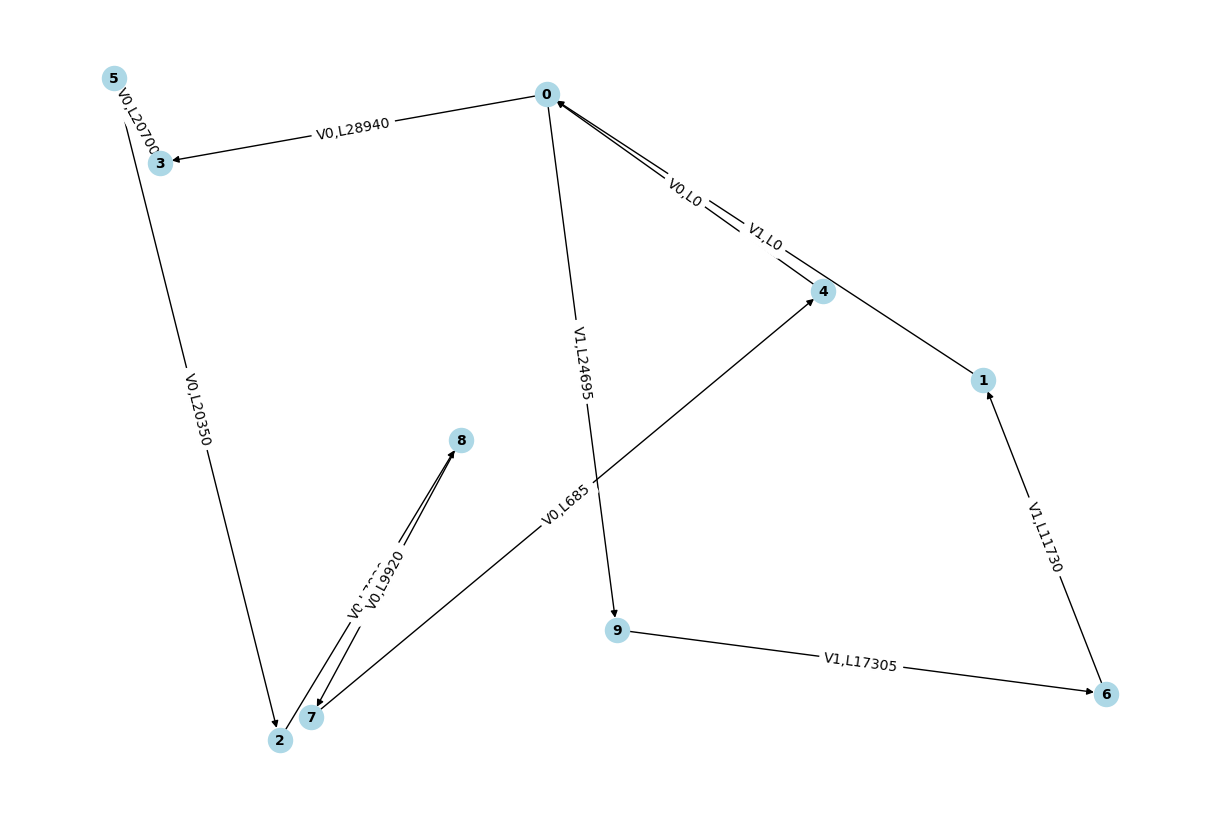

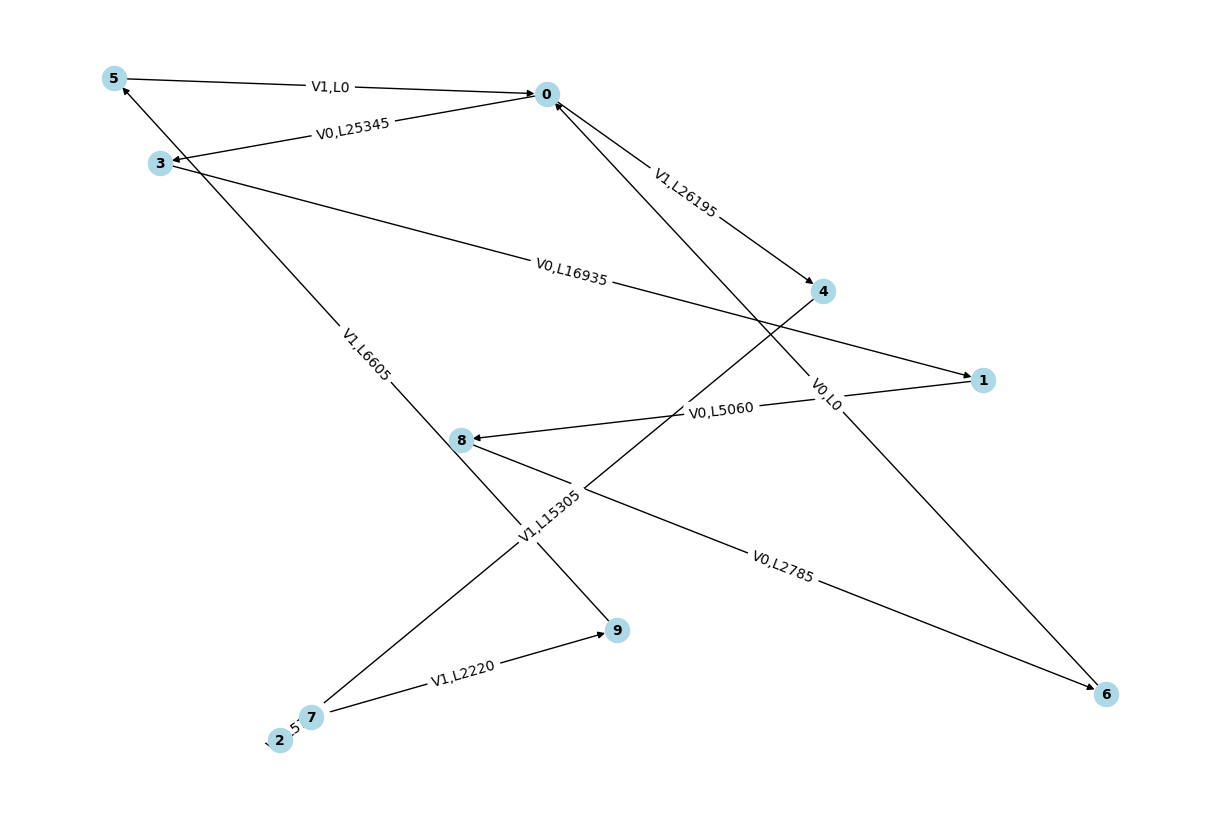

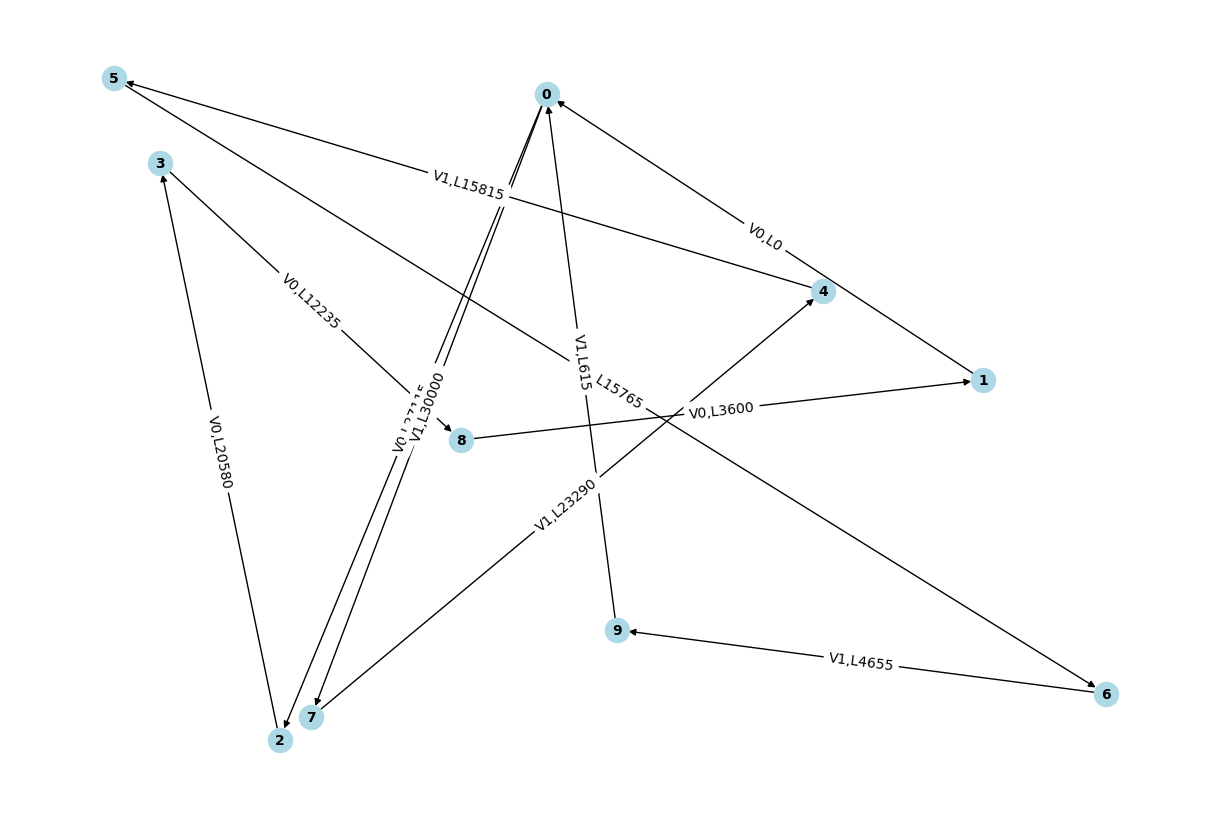

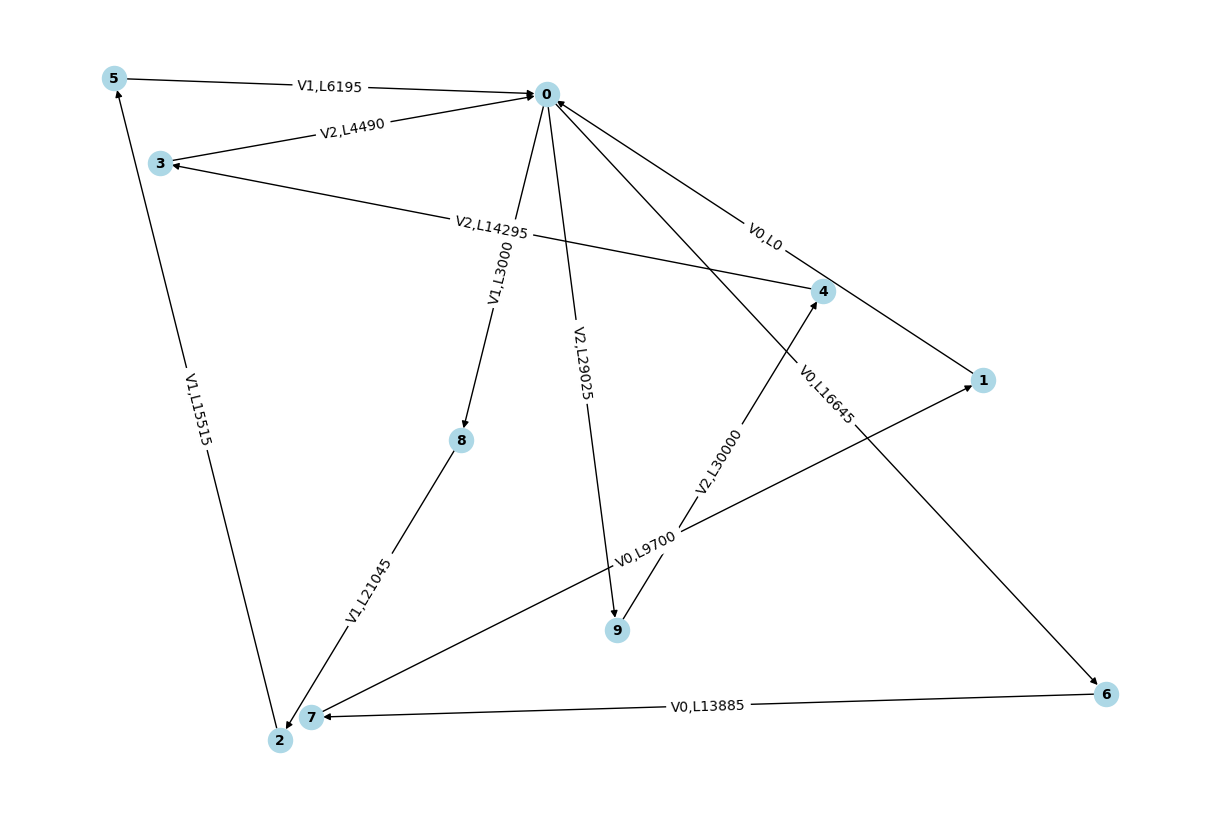

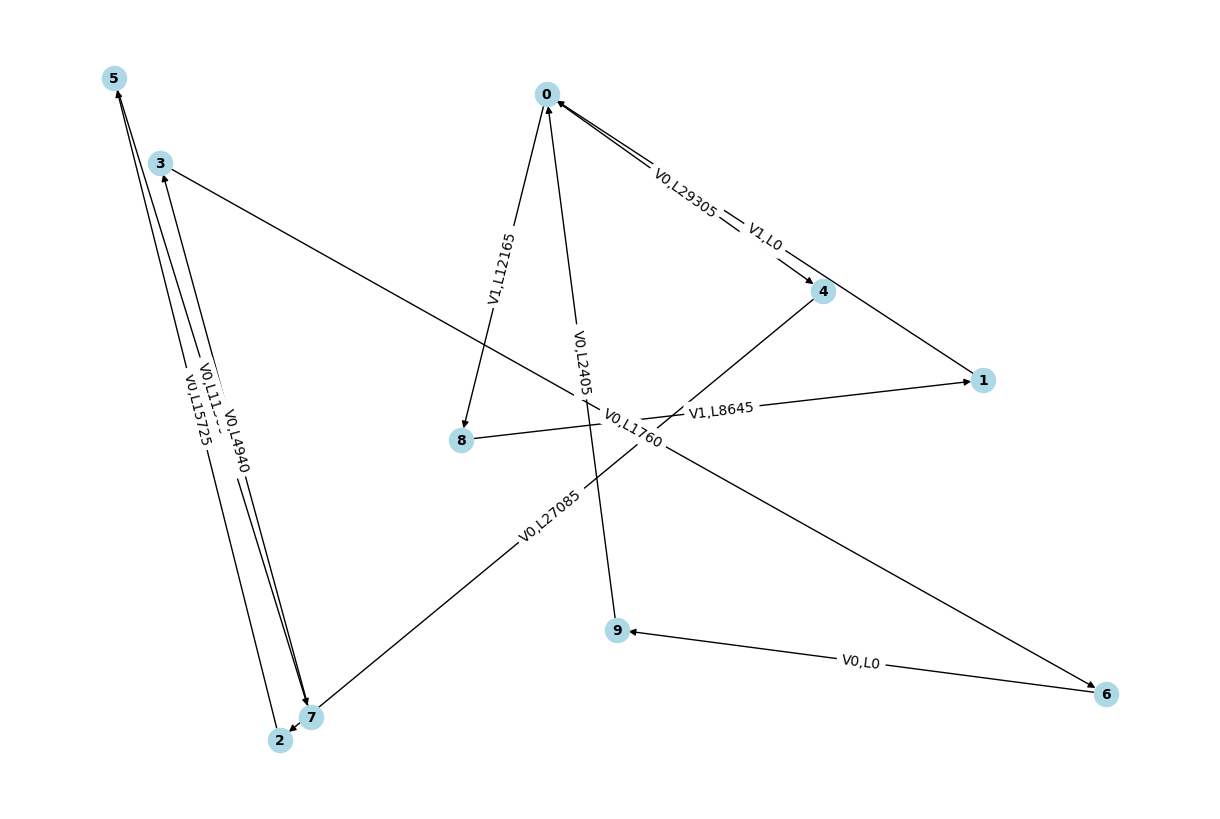

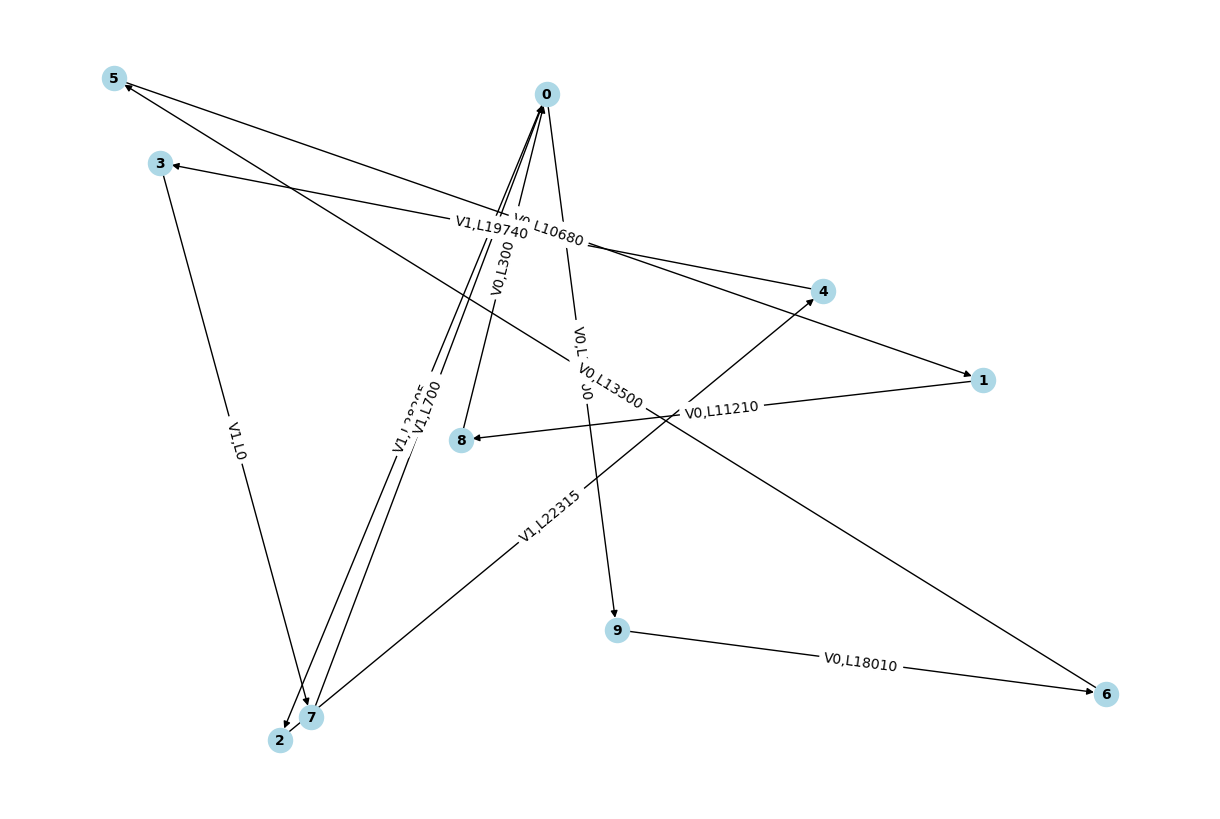

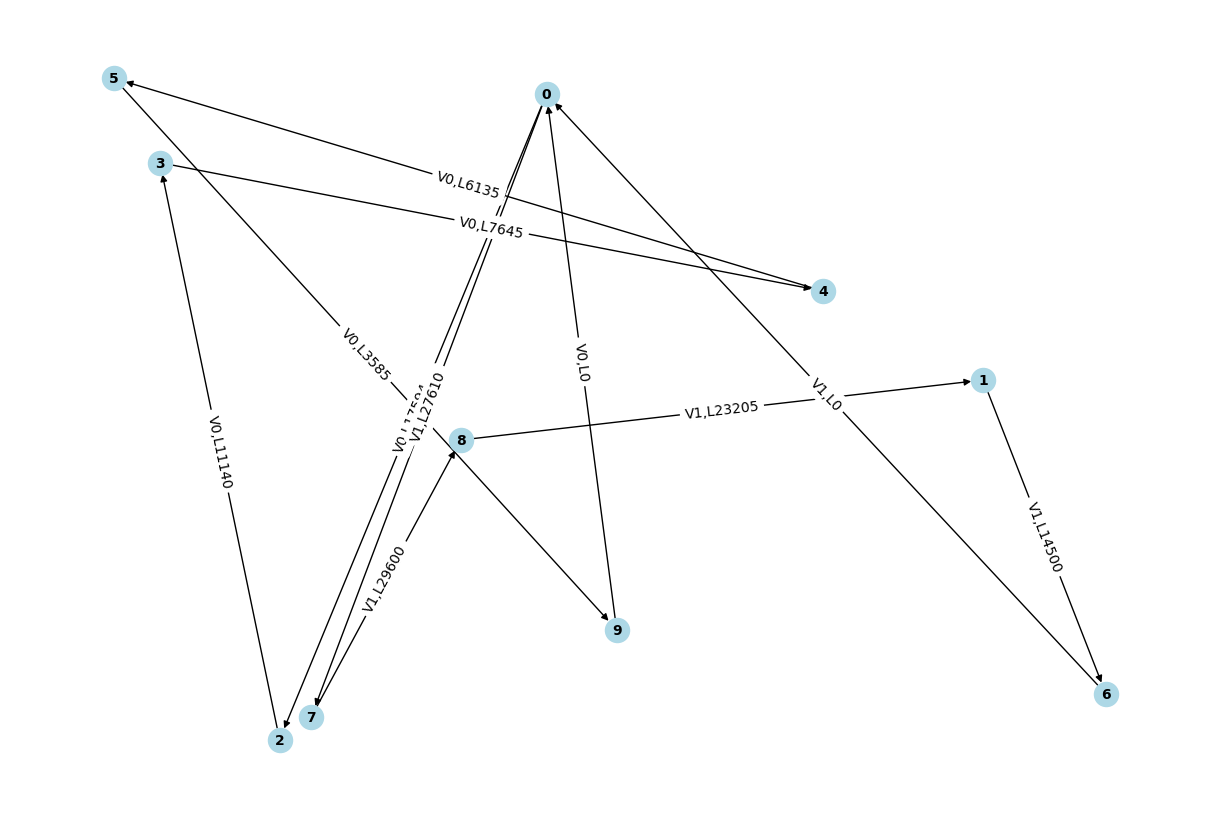

In [29]:
import matplotlib.pyplot as plt
import networkx as nx

def print_routes(routes):
    for k in routes:
        for t in routes[k]:
            if routes[k][t]:
                print(f'Vehicle {k} on Day {t}:')
                current_atm = routes[k][t][0][0]
                path = []
                while routes[k][t]:
                    for i, (start, end) in enumerate(routes[k][t]):
                        if start == current_atm:
                            path.append((start, end))
                            current_atm = end
                            routes[k][t].pop(i)
                            break
                for i, (start, end) in enumerate(path):
                    if i == 0:
                        print(f'  From ATM {start} to ATM {end}', end='')
                    else:
                        print(f', from ATM {start} to ATM {end}', end='')
                print()

def visualize_routes(routes_df, day, coords):
    df = routes_df[(routes_df['Day'] == day)]
    G = nx.DiGraph()
    for atm in ATMSET:
        G.add_node(atm)
    for _, row in df.iterrows():
        G.add_edge(row['From_ATM'], row['To_ATM'], vehicle=row['Vehicle'])
    pos = {node: coords[ATMIDS[node]] for node in G.nodes()}
    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, with_labels=True, node_size=300, node_color='lightblue', font_size=10, font_weight='bold',
            arrows=True)
    edge_labels = {(row['From_ATM'], row['To_ATM']): f"V{int(row['Vehicle'])},L{int(row['Load'])}" for _, row in df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.show()

print_routes(routes)
for day in routes_df['Day'].unique():
    visualize_routes(routes_df, day, atm_locations)

## 参考资料
[1] [《COPT用户手册文档》](https://guide.coap.online/copt/zh-doc/index.html)

[2] Y. Diao, R. Sarkar and E. -E. Jan, "Optimizing ATM cash flow network management," NOMS 2016 - 2016 IEEE/IFIP Network Operations and Management Symposium, Istanbul, Turkey, 2016, pp. 1073-1078, doi: 10.1109/NOMS.2016.7502963. 
